# Excess-of-Loss Layer Pricing
## A Monte Carlo Approach

This notebook prices a per-occurrence Excess-of-Loss (XL) reinsurance layer
using the `reinsure_pricing` engine.

**Treaty structure:** 5M xs 1M — the reinsurer covers losses between 1M and 6M per occurrence.

**Methodology:**
1. Define claim frequency and individual loss severity distributions
2. Simulate 100,000 accident years using the Monte Carlo engine
3. Apply the XL treaty to each simulated year's individual losses
4. Compute risk measures from the resulting ceded loss distribution
5. Derive a risk-adjusted technical premium using a cost-of-capital approach

In [2]:
# Imports
from reinsure_pricing.frequency import PoissonFrequency, NegativeBinomialFrequency
from reinsure_pricing.severity import LognormalSeverity, GammaSeverity, ParetoSeverity
from reinsure_pricing.treaties import ExcessOfLoss
from reinsure_pricing.simulation import MonteCarloEngine
from reinsure_pricing.risk_measures import compute_risk_measures
from reinsure_pricing.pricing import TechnicalPricer
from reinsure_pricing.plots import plot_ceded_loss_distribution, plot_sensitivity
import matplotlib.pyplot as plt

%matplotlib inline

## 1. Distribution Assumptions

We model claim frequency using a **Poisson distribution** with λ = 120,
representing a portfolio generating approximately 120 claims per accident year.

Individual loss severity follows a **Lognormal distribution** with parameters
μ = 10.5 and σ = 1.2 on the log scale. The implied mean individual loss is:

$$E[X] = e^{\mu + \sigma^2/2} = e^{10.5 + 0.72} \approx 332{,}000$$

The lognormal is appropriate here due to its right-skewed shape and empirical
fit to large commercial loss data.

In [3]:
# Frequency distribution
frequency = PoissonFrequency(lambda_=120)
print(f"Frequency — Poisson")
print(f"  Mean claim count : {frequency.mean():.0f}")
print(f"  Variance         : {frequency.variance():.0f}")

# Severity distribution
severity = LognormalSeverity(mu=10.5, sigma=1.2)
print(f"\nSeverity — Lognormal")
print(f"  Mean loss        : {severity.mean():,.0f}")

Frequency — Poisson
  Mean claim count : 120
  Variance         : 120

Severity — Lognormal
  Mean loss        : 74,608


## 2. Treaty Structure

We price a **5M xs 1M** per-occurrence XL layer:

| Parameter | Value |
|---|---|
| Retention | 1,000,000 |
| Limit | 5,000,000 |
| Exhaustion point | 6,000,000 |

The reinsurer pays `min(max(X - 1M, 0), 5M)` for each individual loss X.
Losses below 1M are fully retained by the cedant.
Losses above 6M are partially retained above the exhaustion point.

In [4]:
# Treaty definition
treaty = ExcessOfLoss(retention=1_000_000, limit=5_000_000)

print(f"Treaty: {treaty.limit/1e6:.0f}M xs {treaty.retention/1e6:.0f}M")
print(f"  Retention        : {treaty.retention:>12,.0f}")
print(f"  Limit            : {treaty.limit:>12,.0f}")
print(f"  Exhaustion point : {treaty.upper_limit():>12,.0f}")

Treaty: 5M xs 1M
  Retention        :    1,000,000
  Limit            :    5,000,000
  Exhaustion point :    6,000,000


## 3. Monte Carlo Simulation

We simulate **100,000 accident years**. For each year:
1. Draw a claim count N from Poisson(120)
2. Draw N individual losses from Lognormal(10.5, 1.2)
3. Apply the XL treaty to each loss: `min(max(X - 1M, 0), 5M)`
4. Sum the ceded amounts to get the annual ceded loss

The result is an empirical distribution of 100,000 annual ceded losses.

In [5]:
# Run simulation
engine = MonteCarloEngine(
    frequency=frequency,
    severity=severity,
    treaty=treaty,
    n_simulations=100_000,
    random_state=42,
)
results = engine.run()

print(f"Simulation complete — {len(results.ceded_losses):,} accident years")
print(f"Years with no ceded loss : {(results.ceded_losses == 0).mean():.1%}")
print(f"Years with ceded loss    : {(results.ceded_losses > 0).mean():.1%}")

Simulation complete — 100,000 accident years
Years with no ceded loss : 70.9%
Years with ceded loss    : 29.1%


## 4. Risk Measures

We compute a full suite of risk measures from the empirical ceded loss distribution.

In [6]:
# Compute risk measures
rm = compute_risk_measures(results, treaty_limit=treaty.limit)
print(rm.summary())

─────────────────────────────────────────────
                RISK MEASURES                
─────────────────────────────────────────────
Expected Ceded Loss   :         184,454
Std Deviation         :         515,188
Coeff of Variation    :           2.793
Skewness              :           4.962
─────────────────────────────────────────────
VaR  95%              :       1,083,651
VaR  99%              :       2,542,759
VaR  99.5%            :       3,374,600
─────────────────────────────────────────────
TVaR 95%              :       2,002,855
TVaR 99%              :       3,675,235
TVaR 99.5%            :       4,441,509
─────────────────────────────────────────────
Prob of Attachment    :           29.1%
Prob of Exhaustion    :            0.2%
─────────────────────────────────────────────


## 5. Ceded Loss Distribution

The histogram below shows the distribution of annual ceded losses across
all simulated years. Years with zero ceded loss are excluded from the
histogram body but their proportion is noted in the subtitle.

Key annotations:
- **VaR lines** show the loss levels exceeded in only 5%, 1%, and 0.5% of years
- **TVaR 99%** shows the average loss in the worst 1% of years — the capital proxy
- **Treaty limit** shows where the layer exhausts

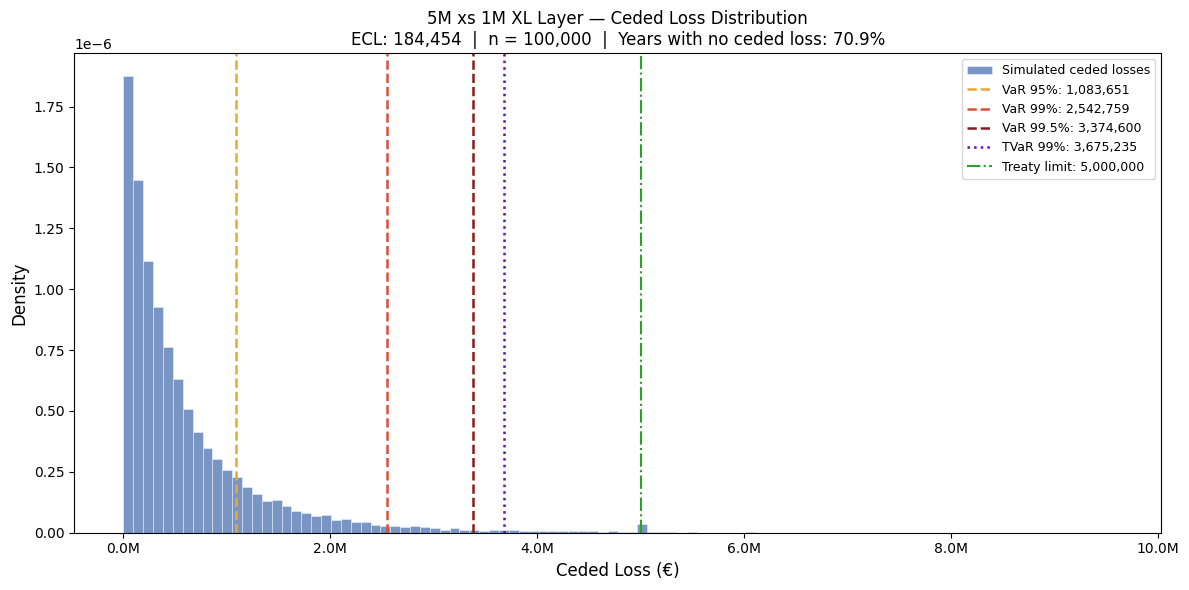

In [7]:
# Plot ceded loss distribution
fig = plot_ceded_loss_distribution(
    results=results,
    risk_measures=rm,
    treaty_limit=treaty.limit,
    title="5M xs 1M XL Layer — Ceded Loss Distribution",
)
plt.show()

## 6. Technical Pricing

The technical premium is built from four components:

$$\text{Premium} = ECL + e \cdot ECL + p \cdot ECL + r_c \cdot \max(TVaR_{99} - ECL,\ 0)$$

| Parameter | Value | Description |
|---|---|---|
| `expense_load` | 5% | Acquisition and admin costs |
| `profit_load` | 8% | Target profit margin |
| `cost_of_capital` | 10% | Required return on risk capital |

In [8]:
# Compute technical premium
pricer = TechnicalPricer(
    expected_ceded_loss=results.expected_ceded_loss,
    tvar_99=results.tvar_99,
    expense_load=0.05,
    profit_load=0.08,
    cost_of_capital=0.10,
)

pricing = pricer.price(treaty_limit=treaty.limit)
print(pricing.summary())

Expected Ceded Loss  :         184,454
Expense Loading      :           9,223
Profit Loading       :          14,756
Capital Load         :         349,078
────────────────────────────────────────
Technical Premium    :         557,511
Rate on Line         :          11.15%


## 7. Sensitivity Analysis — Varying the Retention

We now vary the retention from 500K to 3M, holding all other parameters
constant, to understand how the attachment point affects the technical premium.

Higher retention → fewer losses pierce the layer → lower ECL and premium.

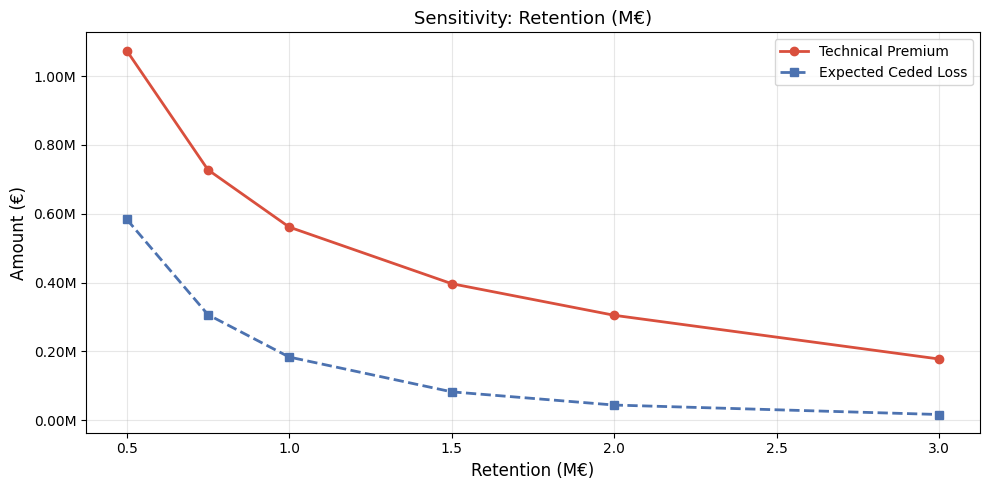

In [9]:
# Sensitivity: vary retention
retentions = [500_000, 750_000, 1_000_000, 1_500_000, 2_000_000, 3_000_000]
premiums_list = []
ecls_list = []

for ret in retentions:
    t = ExcessOfLoss(retention=ret, limit=5_000_000)
    e = MonteCarloEngine(frequency, severity, t,
                         n_simulations=50_000, random_state=42)
    r = e.run()
    p = TechnicalPricer(
        expected_ceded_loss=r.expected_ceded_loss,
        tvar_99=r.tvar_99,
        expense_load=0.05,
        profit_load=0.08,
        cost_of_capital=0.10,
    )
    premiums_list.append(p.technical_premium())
    ecls_list.append(r.expected_ceded_loss)

fig = plot_sensitivity(
    parameter_values=[r/1e6 for r in retentions],
    premiums=premiums_list,
    ecls=ecls_list,
    parameter_name="Retention (M€)",
)
plt.show()

## 8. Summary

| Metric | Value |
|---|---|
| Treaty | 5M xs 1M per occurrence |
| Frequency | Poisson(λ=120) |
| Severity | Lognormal(μ=10.5, σ=1.2) |
| Simulations | 100,000 accident years |
| Expected Ceded Loss | see risk measures above |
| TVaR 99% | see risk measures above |
| Technical Premium | see pricing above |
| Rate on Line | see pricing above |


The technical premium significantly exceeds the ECL due to the large
capital load — the gap between TVaR99 and ECL is substantial for this
high-excess layer, reflecting the heavy tail of the lognormal severity.